# Démo 2 — Entraînement de la Q-table (contrôle Monte-Carlo)

Même algorithme que `notebooks/07` (cf. rapport pour la justification du choix
Monte-Carlo plutôt que TD) — version pédagogique pour la démonstration, en deux
temps :

1. **Estimation** : nombre d'épisodes recommandé pour une convergence correcte
   (repère empirique, cf. `session_notes.md`) et temps estimé **sur cette
   machine**, mesuré par un court calibrage réel.
2. **Entraînement** : tu fixes `EPISODES` (par défaut la valeur recommandée ;
   réduis-la pour une démonstration plus courte — au prix d'une politique moins
   bonne, honnêtement révélée par le contrôle de non-régression final). À la fin,
   le notebook affiche le **temps réel et le temps CPU consommés**, pour chiffrer
   un coût d'entraînement chez un hébergeur cloud.

> Après une modif de `env/` : **Kernel > Restart** avant de relancer.

In [1]:
import importlib
import os
import sys
import time

sys.path.append(os.path.abspath("../env"))
sys.path.append(os.path.abspath("../pricing_agent"))

import numpy as np
import matplotlib.pyplot as plt


def _reload_project():
    for _name in ("refdata", "agents", "market", "gym_wrapper"):
        importlib.reload(importlib.import_module(_name))


_reload_project()
from gym_wrapper import STATE_BINS, TicketEnv, discretize_observation
from registry import model_path, write_meta

HORIZON = 120
_env0 = TicketEnv(horizon=HORIZON)
if "ca_total" not in _env0.reset(seed=0)[1] or not hasattr(_env0, "steps_per_decision"):
    raise RuntimeError("Environnement périmé — fais 'Kernel > Restart Kernel' puis Run All.")

N_STATES = int(np.prod(STATE_BINS))
N_ACTIONS = _env0.action_space.n
print(f"Grille d'états : {STATE_BINS} -> {N_STATES:,} états".replace(",", "'"))
print(f"Cadence : 1 décision / {_env0.steps_per_decision} pas de marché "
      f"-> {HORIZON // _env0.steps_per_decision} décisions/épisode")

Grille d'états : (6' 6' 5' 4' 3' 3) -> 6'480 états
Cadence : 1 décision / 10 pas de marché -> 12 décisions/épisode


In [2]:
# --- Estimation du nombre d'épisodes optimal + temps sur cette machine -------
# Repère empirique (cf. session_notes.md) : sur cette grille (6 480 états),
# ~60 000 épisodes atteignent ~3 400-3 500 états visités et une politique qui
# bat le prix fixe de +6-7% de CA. C'est la valeur "optimale" retenue pour le
# rapport (au-delà, le gain marginal par état visité décroît fortement).
EPISODES_RECOMMANDE = 1000000
_N_CALIB = 300                                        # épisodes de calibrage du débit


def _run_episodes_calib(n, seed0=0):
    # boucle Monte-Carlo minimale (ε=1, pas de sauvegarde) -> calibre le débit réel
    rng = np.random.default_rng(0)
    q = np.zeros((*STATE_BINS, N_ACTIONS))
    for ep in range(n):
        obs, _ = _env0.reset(seed=seed0 + ep)
        state = discretize_observation(obs)
        traj = []
        done = False
        while not done:
            action = int(rng.integers(N_ACTIONS))
            obs, reward, term, trunc, _ = _env0.step(action)
            done = term or trunc
            traj.append((state, action, reward))
            state = discretize_observation(obs)
        g = 0.0
        for st_, a_, r_ in reversed(traj):
            g = r_ + 0.97 * g
            q[st_][a_] += 0.05 * (g - q[st_][a_])


t0 = time.time()
_run_episodes_calib(_N_CALIB)
debit = _N_CALIB / (time.time() - t0)                 # épisodes / seconde

temps_recommande_min = EPISODES_RECOMMANDE / debit / 60
print(f"Débit mesuré sur cette machine (calibrage {_N_CALIB} épisodes) : {debit:.1f} épisodes/s")
print(f"Recommandé : {EPISODES_RECOMMANDE:,} épisodes -> environ {temps_recommande_min:.0f} min".replace(",", "'"))
print("\nPour une démo courte, réduis EPISODES dans la cellule suivante — le contrôle")
print("de non-régression en fin d'entraînement dira honnêtement si la politique")
print("obtenue bat quand même le prix fixe.")

Débit mesuré sur cette machine (calibrage 300 épisodes) : 20.6 épisodes/s
Recommandé : 1'000'000 épisodes -> environ 808 min

Pour une démo courte, réduis EPISODES dans la cellule suivante — le contrôle
de non-régression en fin d'entraînement dira honnêtement si la politique
obtenue bat quand même le prix fixe.


In [3]:
# ============================ PARAMÈTRE ======================================
EPISODES = EPISODES_RECOMMANDE
# ===========================================================================

  épisode 100000/1000000  retour_moyen=30.88
  épisode 200000/1000000  retour_moyen=33.12
  épisode 300000/1000000  retour_moyen=34.13
  épisode 400000/1000000  retour_moyen=35.74
  épisode 500000/1000000  retour_moyen=36.73
  épisode 600000/1000000  retour_moyen=37.34
  épisode 700000/1000000  retour_moyen=39.64
  épisode 800000/1000000  retour_moyen=38.80
  épisode 900000/1000000  retour_moyen=38.81
  épisode 1000000/1000000  retour_moyen=39.58


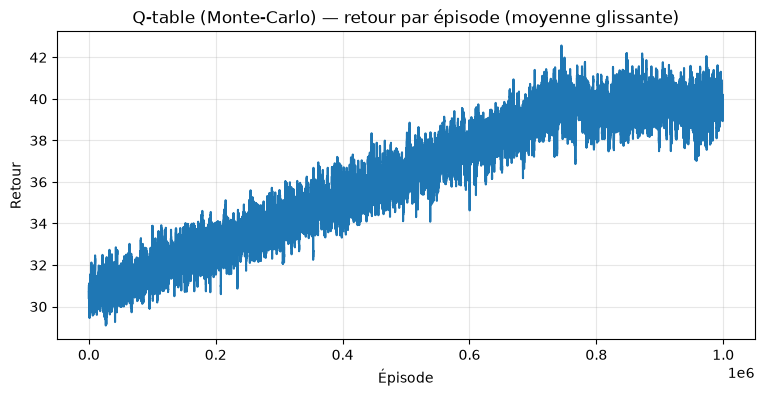


Terminé. États visités : 3450/6480

--- Effort d'entraînement ----------------------------------------------
Temps réel (wall-clock)  : 817.6 min
Temps CPU (process)      : 812.3 min  (99% du temps réel)
Débit                    : 20.4 épisodes/s
Cœurs logiques disponibles : 8
-> devis hébergeur : cette boucle est MONO-CŒUR (le ratio ci-dessus reste
   ~100% sauf parallélisme interne NumPy) -> multiplie le TEMPS RÉEL par le
   tarif horaire d'une petite instance (1-2 vCPU), pas par le nombre de
   cœurs de la machine.


In [4]:
# --- Entraînement Monte-Carlo (identique à notebooks/07) --------------------
alpha, gamma = 0.05, 0.97
eps_start, eps_min, eps_frac = 1.0, 0.06, 0.75
rng = np.random.default_rng(0)
q_table = np.zeros((*STATE_BINS, N_ACTIONS))
episode_returns = []


def epsilon(ep):
    return max(eps_min, eps_start + (eps_min - eps_start) * ep / (eps_frac * EPISODES))


t0_wall, t0_cpu = time.time(), time.process_time()
for episode in range(EPISODES):
    eps = epsilon(episode)
    obs, _ = _env0.reset(seed=episode)
    state = discretize_observation(obs)
    traj = []
    done = False
    while not done:
        action = int(rng.integers(N_ACTIONS)) if rng.random() < eps else int(np.argmax(q_table[state]))
        next_obs, reward, term, trunc, _ = _env0.step(action)
        done = term or trunc
        traj.append((state, action, reward))
        state = discretize_observation(next_obs)
    g = 0.0
    for st_, a_, r_ in reversed(traj):
        g = r_ + gamma * g
        q_table[st_][a_] += alpha * (g - q_table[st_][a_])
    episode_returns.append(float(sum(r_ for _, _, r_ in traj)))
    if (episode + 1) % max(1, EPISODES // 10) == 0:
        print(f"  épisode {episode + 1:>6d}/{EPISODES}  retour_moyen={np.mean(episode_returns[-500:]):.2f}")

wall_s = time.time() - t0_wall
cpu_s = time.process_time() - t0_cpu
visited = int(np.count_nonzero(q_table.any(axis=-1)))

w = min(400, max(1, len(episode_returns) // 5))
smooth = np.convolve(episode_returns, np.ones(w) / w, mode="valid")
plt.figure(figsize=(9, 4))
plt.plot(smooth)
plt.title("Q-table (Monte-Carlo) — retour par épisode (moyenne glissante)")
plt.xlabel("Épisode"); plt.ylabel("Retour")
plt.grid(alpha=0.3)
plt.show()

print(f"\nTerminé. États visités : {visited}/{N_STATES}")
print("\n--- Effort d'entraînement ----------------------------------------------")
print(f"Temps réel (wall-clock)  : {wall_s/60:.1f} min")
print(f"Temps CPU (process)      : {cpu_s/60:.1f} min  ({cpu_s/max(wall_s, 1e-9):.0%} du temps réel)")
print(f"Débit                    : {EPISODES/wall_s:.1f} épisodes/s")
print(f"Cœurs logiques disponibles : {os.cpu_count()}")
print("-> devis hébergeur : cette boucle est MONO-CŒUR (le ratio ci-dessus reste")
print("   ~100% sauf parallélisme interne NumPy) -> multiplie le TEMPS RÉEL par le")
print("   tarif horaire d'une petite instance (1-2 vCPU), pas par le nombre de")
print("   cœurs de la machine.")

In [5]:
# --- Sauvegarde + contrôle de non-régression --------------------------------
final = model_path("q_table")
np.save(final, q_table)
write_meta(final, kind="q_table", method="monte_carlo", episodes=EPISODES, horizon=HORIZON,
           steps_per_decision=_env0.steps_per_decision, seed=0, alpha=alpha, gamma=gamma,
           state_bins=list(STATE_BINS), states_visited=visited, states_total=N_STATES,
           wall_clock_s=round(wall_s, 1), cpu_time_s=round(cpu_s, 1))
print(f"Modèle sauvegardé : {final.name}")
print("QTableAgent.load() (sans argument) renverra désormais ce modèle.")

sys.path.append(os.path.abspath("../scripts"))
from train_qtable import _verify

_verify(q_table, horizon=HORIZON, n_episodes=100)

Modèle sauvegardé : q_table_20260911-094837.npy
QTableAgent.load() (sans argument) renverra désormais ce modèle.
Verification (100 scenarios apparies) : CA vs prix fixe 70 = +9.5%


True